In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from utils.helpers_class import preprocessing
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.width', 500)
pd.set_option('display.float_format', lambda x: '%-3f' % x)
# Set seaborn figure style for ggplot-like aesthetics
sns.set_style("ticks")

# Load the dataset from the folder called 'datesets'
df = pd.read_csv('datasets/winequality-red.csv')
df = sns.load_dataset('titanic')
prep = preprocessing(df)
prep.check_df()
cat_cols, num_cols, cat_but_car = prep.grab_col_names()

#################### Head ####################
   survived  pclass     sex       age  sibsp  parch      fare embarked  class    who  adult_male deck  embark_town alive  alone
0         0       3    male 22.000000      1      0  7.250000        S  Third    man        True  NaN  Southampton    no  False
1         1       1  female 38.000000      1      0 71.283300        C  First  woman       False    C    Cherbourg   yes  False
2         1       3  female 26.000000      0      0  7.925000        S  Third  woman       False  NaN  Southampton   yes   True
3         1       1  female 35.000000      1      0 53.100000        S  First  woman       False    C  Southampton   yes  False
4         0       3    male 35.000000      0      0  8.050000        S  Third    man        True  NaN  Southampton    no   True
#################### Shape ####################
(891, 15)
#################### Data Info ####################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Dat

   survived Variable      mean    median       std         var      min        max  count     skew      sem
0         0      age 30.626179 28.000000 14.172110  200.848698 1.000000  74.000000    424 0.585584 0.688258
1         1      age 28.343690 28.000000 14.950952  223.530965 0.420000  80.000000    290 0.180458 0.877950
2         0     fare 22.117887 10.500000 31.388207  985.219509 0.000000 263.000000    549 4.553140 1.339616
3         1     fare 48.395408 26.000000 66.596998 4435.160158 0.000000 512.329200    342 3.862779 3.601153


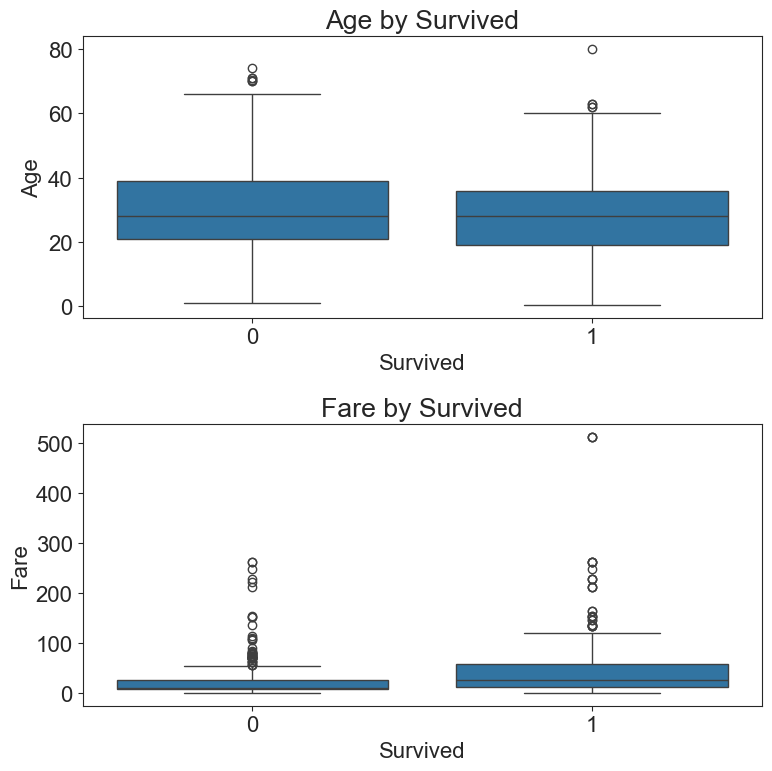

In [6]:
prep.target_summary_with_num('survived', num_cols, plot=True)

       Variable     Category  survived_mean  Count
0           sex       female       0.742038    314
1           sex         male       0.188908    577
2      embarked            C       0.553571    168
3      embarked            Q       0.389610     77
4      embarked            S       0.336957    644
5           who        child       0.590361     83
6           who          man       0.163873    537
7           who        woman       0.756458    271
8   embark_town    Cherbourg       0.553571    168
9   embark_town   Queenstown       0.389610     77
10  embark_town  Southampton       0.336957    644
11        alive           no       0.000000    549
12        alive          yes       1.000000    342
13       pclass            1       0.629630    216
14       pclass            2       0.472826    184
15       pclass            3       0.242363    491
16        sibsp            0       0.345395    608
17        sibsp            1       0.535885    209
18        sibsp            2   

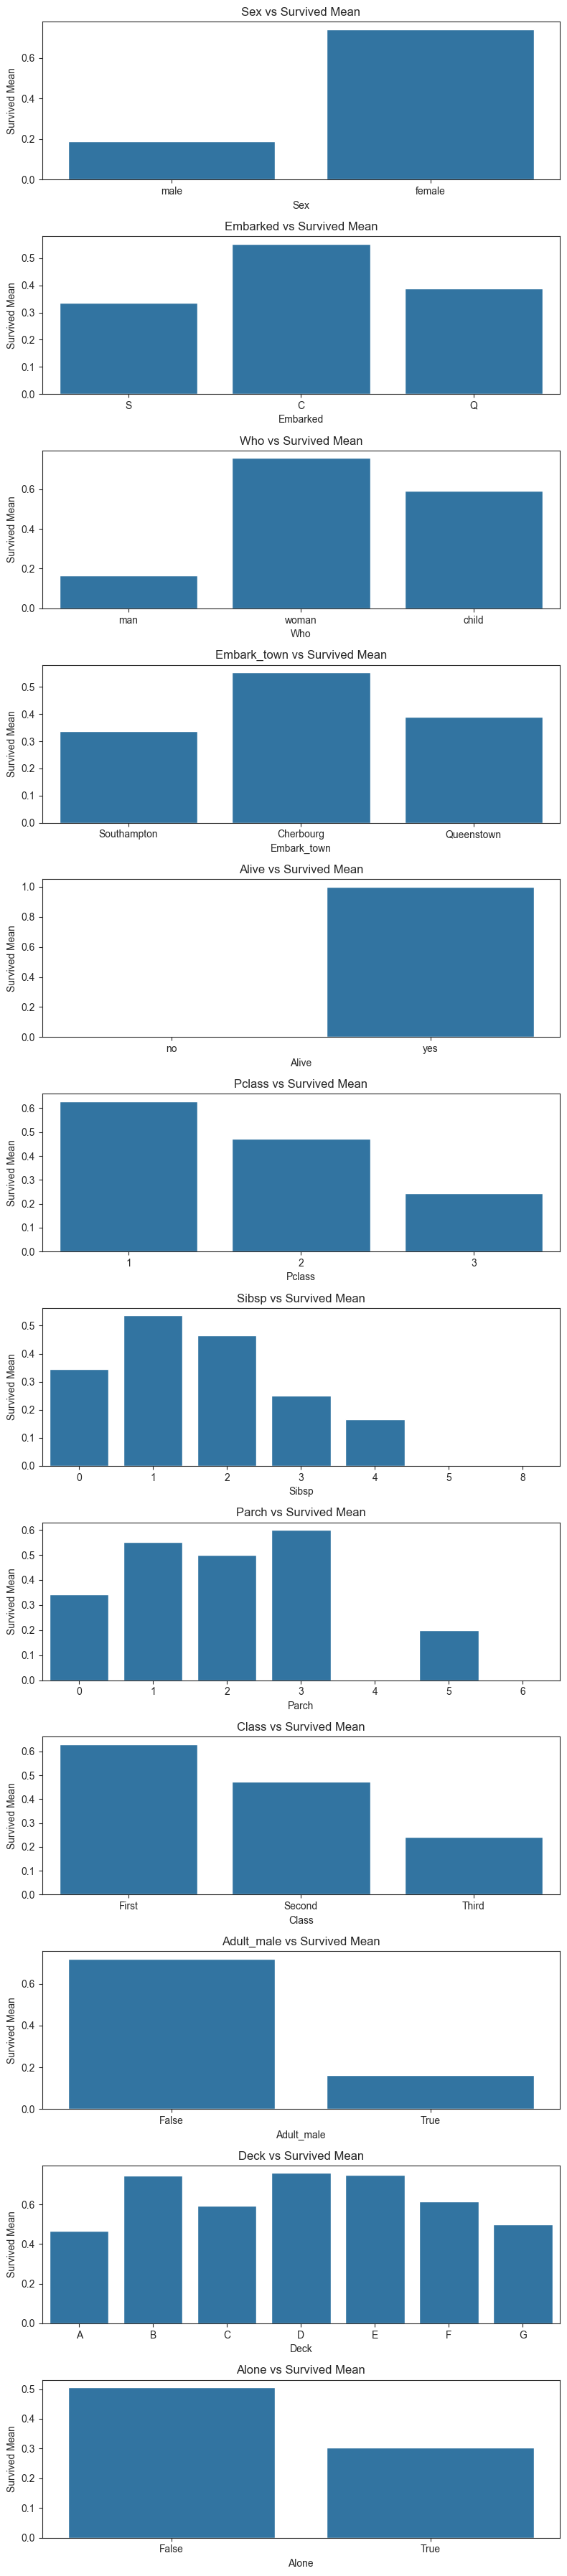

,Variable,Category,survived_mean,Count
0,sex,female,0.742038,314
1,sex,male,0.188908,577
2,embarked,C,0.553571,168
3,embarked,Q,0.389610,77
4,embarked,S,0.336957,644
5,who,child,0.590361,83
6,who,man,0.163873,537
7,who,woman,0.756458,271
8,embark_town,Cherbourg,0.553571,168
9,embark_town,Queenstown,0.389610,77


In [7]:
prep.target_summary_with_cat('survived', cat_cols, plot=True)

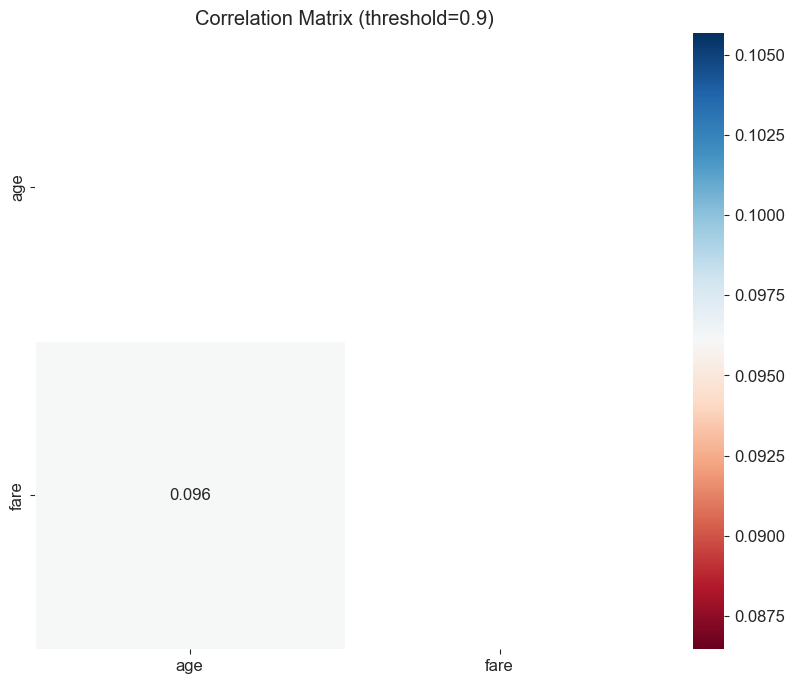

Highly correlated columns (>0.9): []


In [8]:
drop_list, corr_matrix = prep.high_correlated_cols(num_cols, plot=True)